In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp, cumulative_trapezoid, trapezoid
from scipy.interpolate import RegularGridInterpolator
from multiprocessing import Pool
import os
import time
import emcee
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# ====================================================
# Loading CC data
# ====================================================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc  = df_cc["z_cc"].to_numpy(float)
H_obs = df_cc["H_cc"].to_numpy(float)
H_err = df_cc["H_cc_err"].to_numpy(float)


# ====================================================
# Loading FRB data
# ====================================================

frb_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/FRB/frb_catalog.txt"
df_frb       = pd.read_csv(frb_dat_path, sep=r"\t", engine="python")
df_frb       = df_frb.sort_values(by="Redshift", ascending=True).reset_index(drop=True)

z_frb        = df_frb["Redshift"].to_numpy(float)
DM_obs       = df_frb["DM_obs"].to_numpy(float)
DM_MW        = df_frb["DM_MW_ISM_(NE2001)"].to_numpy(float)
DM_halo      = 50
DM_MW_total  = DM_MW + DM_halo       # MW ISM + halo contribution [pc/cm^3]
DM_ext_obs   = DM_obs - DM_MW_total  # extragalactic DM [pc/cm^3]

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,       H0_max       = 50.0,  90.0
Om0_min,      Om0_max      = 0.1,   0.6
b_min,        b_max        = 1.6,   12.0
sig_host_min, sig_host_max = 0.2,   2.0
e_mu_min,     e_mu_max     = 20.0,  200.0

# Gaussian prior on baryon density Ob
mu_Ob, sigma_Ob = 0.0495, 0.0025

# Physical constants (SI)
c_si  = 2.99792458e8       # speed of light [m/s]
G_si  = 6.67430e-11        # gravitational constant [m^3 kg^-1 s^-2]
mp_si = 1.67262192369e-27  # proton mass [kg]

# Unit conversions
km_to_pc = 1.0 / (3.0857e13)
m2_to_cm2 = 1e4
Mpc_to_cm = 3.0857e24

# Astrophysical parameters
f_IGM = 0.83
chi_e = 0.875

# Scalaron mass scale
delta_s = 1e-7


# ====================================================
# Redshift / scale-factor grids
# ====================================================

ai, af = 0.2, 1.0
zi, zf = 0.0, 4.0
N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)

In [4]:
# ====================================================
# Curvature scale (ε) in AB f(R) gravity
# ====================================================

def compute_epsilon(H0, b):
    R_vac = 12.0 * H0**2
    L = np.log1p(np.exp(2.0 * b)) if b < 20.0 else 2.0 * b + np.exp(-2.0 * b)
    return R_vac / L


# ====================================================
# Custom exception for ODE failure
# ====================================================

class ODEFailure(Exception):
    pass


# ====================================================
# ODE system for H(a) in AB f(R) gravity
# ====================================================

def Hubble_AB_a(a, y, H0, Om0, b, epsilon, M2):
    """
    ODE system for H(a) in the AB f(R) model.
    epsilon and M2 are pre-computed outside the integrator.
    """
    
    H, dH, ddH = y

    Om    = Om0 * a**(-3)
    R     = 6.0 * H * (2.0 * H + a * dH)
    alpha = (R / epsilon) - b

    abs_a = abs(alpha)
    if abs_a < 20.0:
        tanh_a = np.tanh(alpha)
        sech_a = 1.0 / np.cosh(alpha)
    else:
        tanh_a = 1.0 if alpha > 0 else -1.0
        sech_a = 2.0 * np.exp(-abs_a)

    A = H0**2 * (3.0 * Om)
    B = a * H * dH * (tanh_a + 1.0)
    C = 4.0 * a * H**2 * dH * (a * dH + 2.0 * H) / M2
    D = ((6.0 * a**2 * H**2 / epsilon)**2
         * ((5.0 * dH / a) + (dH**2 / H) + ddH)**2
         * tanh_a * (sech_a**2))
    E = 6.0 * a**3 * H**3 * (1.0 / (3.0 * M2) + 0.5 * (sech_a**2) / epsilon)

    if E == 0 or not np.isfinite(E):
        raise ODEFailure(f"E singular or non-finite at a={a:.4f}")

    F = ((11.0 * dH**2) / (a * H) + (dH**3) / (H**2)
         + (6.0 * ddH / a) + (4.0 * dH * ddH / H))

    dddH = -(A + B + C - D) / E - F
    return [dH, ddH, dddH]

In [5]:
# ====================================================
# ODE integration → H(a)
# ====================================================

def H_AB_a(a_eval, H0, Om0, b):
    """
    Integrates the AB f(R) ODE system using DOP853.
    epsilon and M2 are pre-computed once and passed
    to the ODE to avoid per-step overhead.
    """

    epsilon = compute_epsilon(H0, b)
    M2      = epsilon / delta_s

    Omi  = Om0 * ai**(-3)
    Ol0  = 1.0 - Om0
    Hi   = H0 * np.sqrt(Omi + Ol0)
    dHi  = -(H0**2) / (2.0 * ai * Hi) * (3.0 * Omi)
    ddHi = (0.5 * (H0 / (ai * Hi))**2 * (Hi + ai * dHi) * (3.0 * Omi)
            + 0.5 * (H0 / (ai * Hi))**2 * Hi * (9.0 * Omi))

    y0 = [Hi, dHi, ddHi]

    try:
        sol = solve_ivp(
            Hubble_AB_a,
            (ai, af),
            y0,
            t_eval=a_eval,
            method="DOP853",
            rtol=1e-5,
            atol=1e-8,
            args=(H0, Om0, b, epsilon, M2),
            dense_output=False
        )
    except ODEFailure:
        return None

    if sol.status < 0 or np.any(~np.isfinite(sol.y)):
        return None

    return sol.y[0]


# ====================================================
# H(z) via a = 1/(1+z) conversion
# ====================================================

def H_AB_z(z_eval, H0, Om0, b):
    """
    Converts z → a, integrates H(a) over [ai, af], and
    returns H(z) in the original ordering of z_eval.
    Points outside the integration domain receive NaN.
    Duplicate a-values are removed before integration
    to avoid instabilities in solve_ivp.
    """
    
    z_eval = np.atleast_1d(np.asarray(z_eval, dtype=float))
    a_eval = 1.0 / (1.0 + z_eval)

    in_domain = (a_eval >= ai) & (a_eval <= af)
    if not np.any(in_domain):
        return None

    valid_idx   = np.where(in_domain)[0]
    a_valid     = a_eval[valid_idx]
    sort_idx    = np.argsort(a_valid)
    a_sorted    = a_valid[sort_idx]
    unique_mask = np.concatenate(([True], np.diff(a_sorted) > 1e-12))
    a_unique    = a_sorted[unique_mask]

    H_unique = H_AB_a(a_unique, H0, Om0, b)
    if H_unique is None:
        return None

    if not np.all(unique_mask):
        H_at_sorted = np.interp(a_sorted, a_unique, H_unique)
    else:
        H_at_sorted = H_unique

    H_valid           = np.empty(len(a_valid))
    H_valid[sort_idx] = H_at_sorted
    H_z               = np.full(len(z_eval), np.nan)
    H_z[valid_idx]    = H_valid

    return H_z

In [6]:
# ====================================================
# Worker function (module level — required for pickle)
# ====================================================

def _grid_worker(args):
    """
    Computes H(z) for a single (H0, Om0, b) grid point.
    Returns (i, j, k, H_values) or (i, j, k, None) on failure.
    """

    i, j, k, H0, Om0, b, z_pts = args
    Hvals = H_AB_z(z_pts, H0, Om0, b)
    if Hvals is not None and np.all(np.isfinite(Hvals)):
        return (i, j, k, Hvals)
    else:
        return (i, j, k, None)


# ====================================================
# Parallel grid builder
# ====================================================

def build_H_grid_parallel(H0_pts, Om0_pts, b_pts, z_pts,
                           n_cores=None, verbose=True):
    """
    Builds the 4D array H[i_H0, i_Om0, i_b, i_z] in parallel
    using multiprocessing.Pool.
    """

    nH  = len(H0_pts)
    nOm = len(Om0_pts)
    nb  = len(b_pts)
    nz  = len(z_pts)

    total   = nH * nOm * nb
    n_cores = n_cores or os.cpu_count()

    tasks = [
        (i, j, k, H0, Om0, b, z_pts)
        for i, H0  in enumerate(H0_pts)
        for j, Om0 in enumerate(Om0_pts)
        for k, b   in enumerate(b_pts)
    ]

    H_array   = np.full((nH, nOm, nb, nz), np.nan)
    nan_count = 0

    if verbose:
        print(f"  Total grid points : {total} ({nH}×{nOm}×{nb})")
        print(f"  Workers           : {n_cores}")
        print(f"  {'PCT':>5}  {'Done':>8}  {'Elapsed':>9}  {'ETA':>9}  {'Rate':>12}")
        print("  " + "-"*55)

    t0       = time.time()
    count    = 0
    last_pct = -1
    chunksize = max(1, total // (n_cores * 20))

    with Pool(processes=n_cores) as pool:
        for result in pool.imap_unordered(_grid_worker, tasks,
                                           chunksize=chunksize):
            i, j, k, Hvals = result
            if Hvals is not None:
                H_array[i, j, k, :] = Hvals
            else:
                nan_count += 1

            count   += 1
            elapsed  = time.time() - t0
            pct      = int(count / total * 100)

            if verbose and (pct >= last_pct + 10 or count == total):
                eta  = (elapsed / count) * (total - count) if count < total else 0.0
                rate = count / elapsed if elapsed > 0 else 0.0
                print(f"  {pct:>4}%  {count:>8}/{total}  "
                      f"{elapsed:>7.1f}s  "
                      f"ETA {eta:>6.1f}s  "
                      f"{rate:>8.1f} pts/s")
                last_pct = pct

    nan_frac = nan_count / total
    if nan_frac > 0:
        print(f"\n  ⚠  {100*nan_frac:.1f}% NaN in grid — "
              f"check prior bounds or ODE stability.")
    else:
        print(f"\n  ✓  Grid complete with no NaN points.")

    total_time = time.time() - t0
    print(f"  Total time: {total_time:.1f}s ({total_time/60:.2f} min)")

    return H_array


# ====================================================
# Interpolation error validation
# ====================================================

def validate_interpolation_error(H_interp_4D, H0_pts, Om0_pts, b_pts, z_pts,
                                  n_test=300, tol_percent=0.5):
    """
    Validates the interpolator against direct ODE solutions at
    n_test random interior points.
    """

    rng_v  = np.random.default_rng(0)
    errors = []

    for _ in range(n_test):
        H0_t  = rng_v.uniform(H0_pts[1],  H0_pts[-2])
        Om0_t = rng_v.uniform(Om0_pts[1], Om0_pts[-2])
        b_t   = rng_v.uniform(b_pts[1],   b_pts[-2])

        H_true = H_AB_z(z_pts, H0_t, Om0_t, b_t)
        if H_true is None or not np.all(np.isfinite(H_true)):
            continue

        pts      = np.column_stack([np.full(len(z_pts), H0_t),
                                    np.full(len(z_pts), Om0_t),
                                    np.full(len(z_pts), b_t),
                                    z_pts])
        H_interp = H_interp_4D(pts)
        rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
        errors.append(np.max(rel_err))

    errors = np.array(errors)

    print(f"\n  Interpolation validation ({n_test} random interior points):")
    print(f"  Max error    : {errors.max():.4f}%")
    print(f"  Median error : {np.median(errors):.4f}%")
    print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")

    if errors.max() < tol_percent:
        print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
              f"Ready for MCMC.")
    else:
        print(f"  ✗  Max error exceeds {tol_percent}%! "
              f"Increase grid resolution (n_H0, n_Om0, n_b).")

    return errors


# ====================================================
# 4D interpolation grid parameters
# ====================================================

n_H0  = 30
n_Om0 = 30
n_b   = 30

H0_grid_pts  = np.linspace(H0_min,  H0_max,  n_H0)
Om0_grid_pts = np.linspace(Om0_min, Om0_max, n_Om0)
b_grid_pts   = np.linspace(b_min,   b_max,   n_b)


# ====================================================
# Build grid (parallel)
# ====================================================

print("\n=== Building 4D interpolation grid (parallel) ===")
H_array = build_H_grid_parallel(
    H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid,
    n_cores=112
)


# ====================================================
# Build interpolator
# ====================================================

H_interp_4D = RegularGridInterpolator(
    (H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid),
    H_array,
    method="linear",
    bounds_error=False,
    fill_value=np.nan       # explicit NaN outside grid bounds
)


# ====================================================
# Validate interpolator
# ====================================================

print("\n=== Validating interpolator ===")
errors = validate_interpolation_error(
    H_interp_4D, H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid
)


=== Building 4D interpolation grid (parallel) ===
  Total grid points : 27000 (30×30×30)
  Workers           : 112
    PCT      Done    Elapsed        ETA          Rate
  -------------------------------------------------------
     9%      2430/27000     17.6s  ETA  178.2s     137.9 pts/s
    19%      5130/27000     32.4s  ETA  138.2s     158.3 pts/s
    29%      7831/27000     49.5s  ETA  121.2s     158.2 pts/s
    39%     10530/27000     69.0s  ETA  108.0s     152.6 pts/s
    49%     13230/27000     89.3s  ETA   92.9s     148.2 pts/s
    59%     15930/27000    110.5s  ETA   76.8s     144.2 pts/s
    69%     18630/27000    131.2s  ETA   58.9s     142.0 pts/s
    79%     21330/27000    152.3s  ETA   40.5s     140.1 pts/s
    89%     24030/27000    167.7s  ETA   20.7s     143.3 pts/s
    99%     26730/27000    180.5s  ETA    1.8s     148.1 pts/s
   100%     27000/27000    182.3s  ETA    0.0s     148.1 pts/s

  ✓  Grid complete with no NaN points.
  Total time: 182.7s (3.05 min)

=== Va

In [7]:
# ====================================================
# H(z) via interpolator — used inside MCMC likelihood
# ====================================================

def H_AB_interp(z_eval, H0, Om0, b):
    pts = np.column_stack([
        np.full(len(z_eval), H0),
        np.full(len(z_eval), Om0),
        np.full(len(z_eval), b),
        z_eval
    ])
    return H_interp_4D(pts)


# ====================================================
# Quick test
# ====================================================

print("\n=== Interpolator test ===")
print("H_AB_cc_interp(z_cc) =", H_AB_interp(z_cc, 70.0, 0.3, 2.5))


=== Interpolator test ===
H_AB_cc_interp(z_cc) = [ 74.90553982  75.58357734  76.62852596  78.44926874  78.78743914
  79.54978252  79.5881207   82.38787839  82.80374895  85.92223412
  87.20199161  88.11964497  88.13827064  89.2883467   90.49691089
  91.49680735  91.91101986  91.99585857  97.92386164 102.84381391
 107.02278419 107.02278419 108.9357689  110.12600201 114.95969067
 115.2891818  116.61736591 126.09948672 142.85575874 146.01843925
 151.08854862 156.59515596 165.02265511 184.38001396 204.30363028]


In [8]:
# ====================================================
# DM_IGM(z) via interpolator — used inside MCMC likelihood
# ====================================================


def DM_IGM_AB_interp(z, H0, Om0, Ob, b):

    prefactor = 3.0 * c_si * f_IGM * chi_e / (8.0 * np.pi * G_si * mp_si)

    H_interp   = H_AB_interp(z_grid, H0, Om0, b)
    integrand  = (1 + z_grid) / H_interp
    I_interp   = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z_interp = np.interp(z, z_grid, I_interp)

    DM_IGM_interp  = prefactor * Ob * H0**2 * I_z_interp        
    DM_corr_interp = DM_IGM_interp * (km_to_pc / (m2_to_cm2 * Mpc_to_cm)) 

    return DM_corr_interp


# ====================================================
# Quick test
# ====================================================

print("\n=== Interpolator test ===")
print("DM_IGM_AB_interp(z_frb) =", DM_IGM_AB_interp(z_frb, 70, 0.3, 0.0495, 2.5))


=== Interpolator test ===
DM_IGM_AB_interp(z_frb) = [   6.96486112   15.60294427   19.47132963   24.53676458   24.90262495
   35.3023902    35.56280263   38.7949311    50.0033535    53.1731628
   53.51037656   54.77492814   58.24864099   59.36877634   59.52152206
   60.7095444    65.29191627   74.76065175   77.4080467    78.60498557
   82.1279837    88.14285854   90.5095714    90.63923085   92.45446315
   95.82560885   99.17946663   99.71539236   99.80183199  103.0960089
  103.21772273  106.74742379  107.18211604  109.18170039  109.79026954
  117.11550314  119.82562554  124.10936742  133.33469981  133.42259409
  134.51160411  136.76378737  151.2679996   157.21725768  164.25143644
  164.96523439  165.08122656  175.50928818  180.52918883  181.87380507
  184.56486361  197.6273855   202.14906993  204.40991215  207.1229228
  208.84068754  209.6607036   210.47799535  212.11257884  217.10713953
  217.28875992  228.03460195  235.79642918  240.73873885  242.66074816
  243.7590392   248.3194888

In [9]:
# ====================================================
# CC + FRB likelihood
# ====================================================

# Toggle: Choose a prior for b
USE_LOG_b_PRIOR = False   # True = Jeffreys (log b) | False = Uniform (b)

# Bounds
if USE_LOG_b_PRIOR:
    b_param_min = np.log(b_min)
    b_param_max = np.log(500.0)
else:
    b_param_min = b_min
    b_param_max = b_max


# Log-prior
def lnprior_cc_frb(theta):
    H0, Om0, Ob, b_param, sigma_host, exp_mu = theta
    if not (H0_min       <= H0         <= H0_max):       return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):      return -np.inf
    if not (0.0          <  Ob         <  Om0):          return -np.inf
    if not (b_param_min  <= b_param    <= b_param_max):  return -np.inf
    if not (sig_host_min <= sigma_host <= sig_host_max): return -np.inf
    if not (e_mu_min     <= exp_mu     <= e_mu_max):     return -np.inf
    lp_Ob = -0.5 * ((Ob - mu_Ob) / sigma_Ob)**2
    return lp_Ob


# Convolved FRB PDF: IGM (Gaussian) + host galaxy (log-normal)
def P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean, sigma_IGM,
                         sigma_host, exp_mu, npts=300):
    
    mu_host      = np.log(exp_mu)
    upper        = max(DM_ext_obs.max(), 5.0 * exp_mu)
    DM_hosp_grid = np.linspace(1e-2, upper, npts)
    DM_hosp_grid = DM_hosp_grid[None, :]                        # (1, npts)
    DM_ext_array      = DM_ext_obs[:, None]                     # (N, 1)
    DM_IGM_array      = DM_ext_array - DM_hosp_grid / (1 + z_frb[:, None])
    sigma_IGM_array   = sigma_IGM[:, None]
    DM_IGM_mean_array = DM_IGM_mean[:, None]
    
    # IGM PDF (Gaussian)
    P_IGM = (1.0 / (np.sqrt(2*np.pi) * sigma_IGM_array)) \
            * np.exp(-0.5 * ((DM_IGM_array - DM_IGM_mean_array) / sigma_IGM_array)**2)
    
    # Host galaxy PDF (log-normal)
    DM_hosp_array = DM_hosp_grid
    P_host = (1.0 / (np.sqrt(2*np.pi) * sigma_host * DM_hosp_array)) \
             * np.exp(-0.5 * ((np.log(DM_hosp_array) - mu_host) / sigma_host)**2)
    
    # Convolution via numerical integration over DM_host
    integrand = P_IGM * P_host                                  # (N, npts)
    P_total   = trapezoid(integrand, x=DM_hosp_grid[0], axis=1)
    return np.maximum(P_total, 1e-100)


# Joint likelihood
def lnlike_cc_frb(theta, z_cc, H_obs, H_err, z_frb, DM_ext_obs):
    H0, Om0, Ob, b_param, sigma_host, exp_mu = theta
    b = np.exp(b_param) if USE_LOG_b_PRIOR else b_param
    
    # --- CC ---
    H_model = H_AB_interp(z_cc, H0, Om0, b)
    if not np.all(np.isfinite(H_model)):
        return -np.inf
    lnL_cc = -0.5 * np.sum(((H_obs - H_model) / H_err)**2)
    
    # --- FRB ---
    DM_IGM_mean = DM_IGM_AB_interp(z_frb, H0, Om0, Ob, b)
    if not np.all(np.isfinite(DM_IGM_mean)):
        return -np.inf
    sigma_IGM = 173.8 * (z_frb**0.4)
    P_total   = P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean,
                                     sigma_IGM, sigma_host, exp_mu)
    lnL_frb = np.sum(np.log(P_total))
    return lnL_cc + lnL_frb


# Joint posterior
def lnprob_cc_frb(theta, z_cc, H_obs, H_err, z_frb, DM_ext_obs):
    lp = lnprior_cc_frb(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_cc_frb(theta, z_cc, H_obs, H_err, z_frb, DM_ext_obs)


# ====================================================
# Quick test
# ====================================================

b_test     = np.log(3.0) if USE_LOG_b_PRIOR else 3.0
theta_test = [70.0, 0.3, 0.0495, b_test, 0.7, 120.0]
print("\n=== CC + FRB posterior test ===")
print(f"Prior type : {'Jeffreys (log b)' if USE_LOG_b_PRIOR else 'Uniform (b)'}")
print("CC + FRB log-posterior =",
      lnprob_cc_frb(theta_test, z_cc, H_obs, H_err, z_frb, DM_ext_obs))


=== CC + FRB posterior test ===
Prior type : Uniform (b)
CC + FRB log-posterior = -658.5834001580472


In [ ]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 6
nwalkers = 48
nsteps   = 50000

b_init = np.log(2.5) if USE_LOG_b_PRIOR else 2.5
bscale = 0.3         if USE_LOG_b_PRIOR else 0.1

theta0 = np.array([70.0, 0.3, 0.0495, b_init, 0.7, 120.0])
scales = np.array([ 2.0, 0.02, 0.001, bscale, 0.1,  10.0])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))

for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_frb(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (CC + FRB | {'Jeffreys' if USE_LOG_b_PRIOR else 'Uniform'} prior) ===")
t_mcmc = time.time()

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc_frb,
    args=(z_cc, H_obs, H_err, z_frb, DM_ext_obs)
)

sampler.run_mcmc(p0, nsteps, progress=True)
print(f"\nMCMC completed in {(time.time() - t_mcmc) / 60:.1f} min")


=== Running MCMC (CC + FRB | Uniform prior) ===


100%|██████████| 50000/50000 [39:15<00:00, 21.22it/s]


MCMC completed in 39.3 min


In [11]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]

acc_frac = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn        = int(3 * tau_max)
n_post       = nsteps_total - nburn
N_eff        = nwalkers * (n_post / tau)
N_eff_min    = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.481
Acceptance status: IDEAL

Max autocorrelation time τ_max = 92.79
Chain length / τ_max           = 538.9
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 278 steps (0.6%)
Minimum N_eff                  = 25721
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [ ]:
# ====================================================
# Chain extraction — converter log_b → b if needed
# ====================================================

# flat_log     = sampler.get_chain(discard=nburn, thin=nthin, flat=True)      # Apply thin
flat_log     = sampler.get_chain(discard=nburn, flat=True)                    # No thin
flat_samples = flat_log.copy()
if USE_LOG_b_PRIOR:
    flat_samples[:, 3] = np.exp(flat_log[:, 3])

fname = "flat_samples_AB_cc_frb_jeff.npy" if USE_LOG_b_PRIOR else "flat_samples_AB_cc_frb.npy"
np.save(fname, flat_samples)
print(f"\nFinal posterior samples : {len(flat_samples)}")
print(f"Burn-in used            : {nburn} steps")
# print(f"Thin                      : {nthin}")
print(f"Saved to                : {fname}")


Final posterior samples : 2386656
Burn-in used            : 278 steps
Saved to                : flat_samples_AB_cc_frb.npy


Removed no burn in


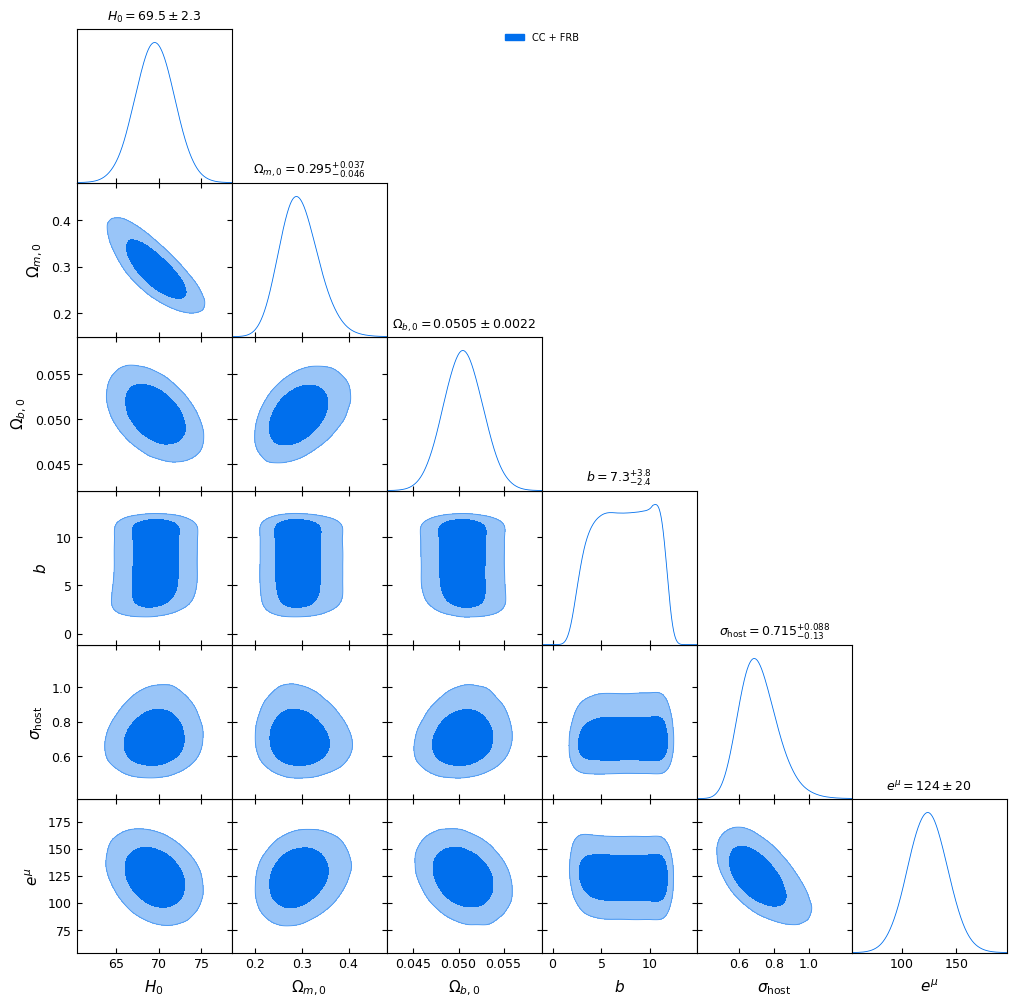

In [13]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "b", "sigma_host", "exp_mu"]
param_labels = [r"H_0", r"\Omega_{m,0}", r"\Omega_{b,0}", r"b",
                r"\sigma_{\rm host}", r"e^\mu"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)
samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 12
g.settings.lab_fontsize        = 14
g.settings.legend_fontsize     = 10
g.settings.linewidth_contour   = 1.2
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3
g.triangle_plot(samples_gd, filled=True,
                legend_labels=["CC + FRB"],
                title_limit=1)

figname = "Corner_AB_cc_frb_jeff.png" if USE_LOG_b_PRIOR else "Corner_AB_cc_frb.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# ====================================================
# Marginalized statistics
# ====================================================

marge = samples_gd.getMargeStats()
print("\n" + "="*60)
print(f"{'FINAL INFERENCE RESULTS (AB + CC + FRB)':^60}")
print("="*60)

for name in ["H0", "Om0", "Ob", "sigma_host", "exp_mu"]:
    stats = marge.parWithName(name)
    print(f"\n  {name}:")
    print(f"    Mean ± 1σ : {stats.mean:.4f} ± {stats.err:.4f}")
    print(f"    95% CL    : [{stats.limits[1].lower:.4f}, "
          f"{stats.limits[1].upper:.4f}]")

stats_b = marge.parWithName("b")
print(f"\n  b  (unconstrained from above):")
print(f"    95% lower limit : b > {stats_b.limits[1].lower:.2f}")
print("\n" + "="*60)


          FINAL INFERENCE RESULTS (AB + CC + FRB)           

  H0:
    Mean ± 1σ : 69.5344 ± 2.3463
    95% CL    : [64.9090, 74.1234]

  Om0:
    Mean ± 1σ : 0.2952 ± 0.0420
    95% CL    : [0.2157, 0.3791]

  Ob:
    Mean ± 1σ : 0.0505 ± 0.0022
    95% CL    : [0.0463, 0.0549]

  sigma_host:
    Mean ± 1σ : 0.7150 ± 0.1122
    95% CL    : [0.5082, 0.9402]

  exp_mu:
    Mean ± 1σ : 123.7603 ± 18.2782
    95% CL    : [88.1813, 159.8422]

  b  (unconstrained from above):
    95% lower limit : b > 2.60



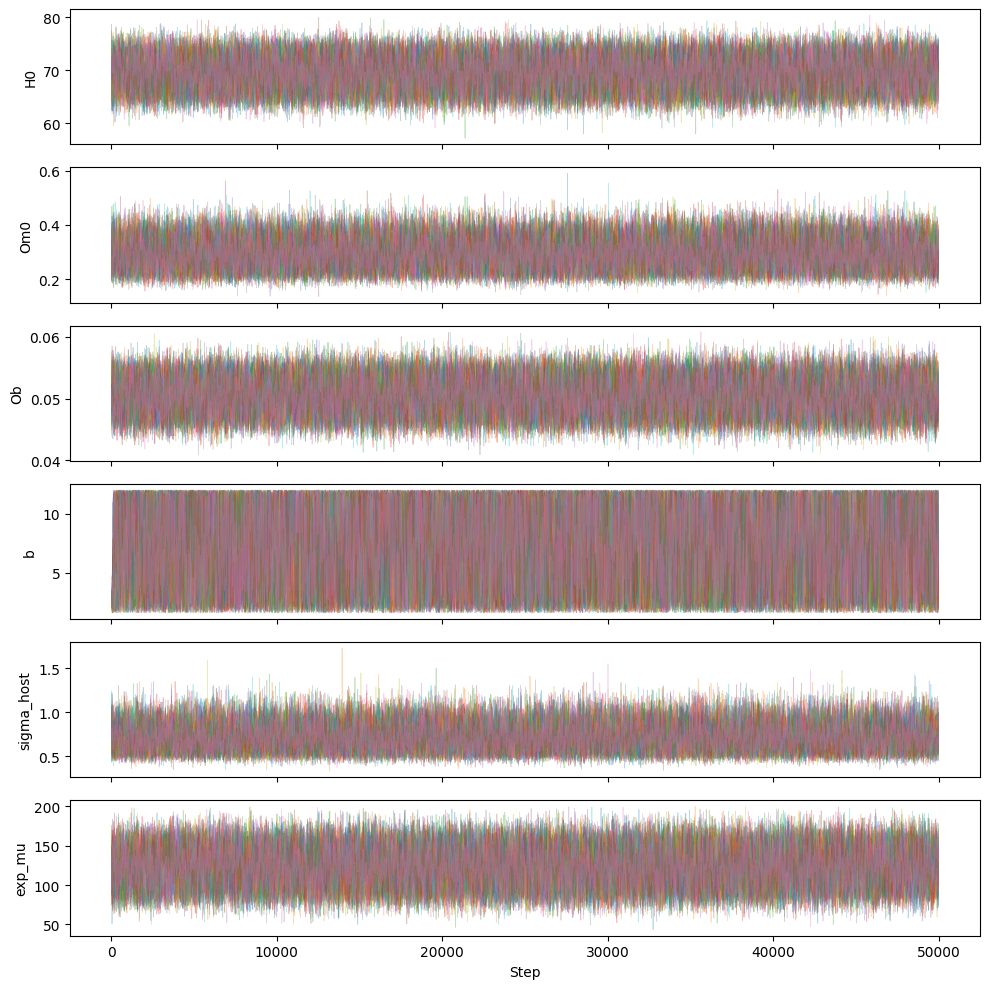

In [15]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()
if USE_LOG_b_PRIOR:
    chain_plot[:, :, 3] = np.exp(chain_plot[:, :, 3])

fig, axes = plt.subplots(6, figsize=(10, 10), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "b", "sigma_host", "exp_mu"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()